# Part 2: Data Layer — Drift Simulation & Detection

## Objective
In this session, you will:
1. Understand data drift and its impact on model performance
2. Create shifted datasets (brightness, contrast variations)
3. Compare input data distributions using histograms
4. Calculate KL divergence to quantify distribution shift
5. Measure accuracy degradation under data drift
6. Implement drift detection with monitoring logic

## Key Concepts
- **Data Drift**: Changes in input data distribution over time
- **Covariate Shift**: Distribution of features changes
- **Concept Drift**: Relationship between features and target changes
- **KL Divergence**: Measure of how different two distributions are
- **Drift Detection**: Automated alerts when model performance drops

## Why Data Drift Matters

**Real-world Example**: ADAS (Advanced Driver Assistance Systems)
- Model trained on daytime highway footage
- Deployed at night or in rain -> Images much darker
- Model accuracy drops from 95% -> 70%
- But code hasn't changed - **DATA CHANGED**

**Other Examples**:
- Economic crisis changes user spending patterns
- Camera hardware changed = different image quality
- Seasonal changes in weather/lighting
- Model degradation is silent - no alerts!

---
## Step 1: Setup & Load Original Dataset

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageEnhance
from scipy.stats import entropy
from collections import defaultdict

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

print("Libraries imported")

Libraries imported


In [2]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['animal', 'name_board', 'pedestrian', 'pothole', 'road_sign', 'speed_breaker', 'vehicle']
num_classes = len(class_names)

print(f"Device: {device}")
print(f"Classes: {class_names}")

# Dataset paths
DATASET_PATH = r"C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\dataset"
TEST_PATH = os.path.join(DATASET_PATH, "test")

print(f"Dataset path: {TEST_PATH}")

Device: cuda
Classes: ['animal', 'name_board', 'pedestrian', 'pothole', 'road_sign', 'speed_breaker', 'vehicle']
Dataset path: C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\dataset\test


---
## Step 2: Load Model & Dataset

In [3]:
# Image preprocessing — MUST match the training/serving pipeline
# (128x128 + ImageNet normalization). This is the "clean" transform applied
# to BOTH the original and the drift-shifted datasets.
transform_base = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Original (un-shifted) test set used as the drift baseline
test_dataset = ImageFolder(TEST_PATH, transform=transform_base)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Trained checkpoint (produced by class1/Part_2_Overfitting_and_Generalization.ipynb).
# Anchored to the repo so it resolves regardless of the notebook's working directory.
MODEL_PATH = os.path.join(os.path.dirname(DATASET_PATH), "class2", "models", "v1", "model.pth")

print(f"Test images: {len(test_dataset)}  |  classes: {test_dataset.classes}")
print(f"Model path : {MODEL_PATH}")
print(f"Model file exists: {os.path.exists(MODEL_PATH)}")

Test images: 117  |  classes: ['animal', 'name_board', 'pedestrian', 'pothole', 'road_sign', 'speed_breaker', 'vehicle']
Model path : C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\class2\models\v1\model.pth
Model file exists: True


---
## Step 3: Create Drift-Shifted Datasets

We simulate two types of data drift:
- **Brightness shift** (0.1x) — simulates night-time or very cloudy conditions
- **Contrast shift** (0.2x) — simulates heavy fog or degraded camera quality

In [4]:
class BrightnessShiftedDataset(torch.utils.data.Dataset):
    """Simulates data drift by reducing image brightness"""
    def __init__(self, original_dataset, brightness_factor=0.1):
        self.original_dataset = original_dataset
        self.brightness_factor = brightness_factor
        self.transform = transform_base

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        image_path, label = self.original_dataset.imgs[idx]
        image = Image.open(image_path).convert('RGB')
        enhancer = ImageEnhance.Brightness(image)
        image = enhancer.enhance(self.brightness_factor)
        image = self.transform(image)
        return image, label

try:
    brightness_shifted_dataset = BrightnessShiftedDataset(test_dataset, brightness_factor=0.8)
    brightness_shifted_loader = DataLoader(brightness_shifted_dataset, batch_size=32, shuffle=False)
    print("Brightness-shifted dataset created (factor=0.1)")
except Exception as e:
    print(f"Could not load brightness-shifted dataset: {e}")

Brightness-shifted dataset created (factor=0.1)


In [5]:
class ContrastShiftedDataset(torch.utils.data.Dataset):
    """Simulates data drift by reducing image contrast"""
    def __init__(self, original_dataset, contrast_factor=0.2):
        self.original_dataset = original_dataset
        self.contrast_factor = contrast_factor
        self.transform = transform_base

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        image_path, label = self.original_dataset.imgs[idx]
        image = Image.open(image_path).convert('RGB')
        enhancer = ImageEnhance.Contrast(image)
        image = enhancer.enhance(self.contrast_factor)
        image = self.transform(image)
        return image, label

try:
    contrast_shifted_dataset = ContrastShiftedDataset(test_dataset, contrast_factor=0.2)
    contrast_shifted_loader = DataLoader(contrast_shifted_dataset, batch_size=32, shuffle=False)
    print("Contrast-shifted dataset created (factor=0.2)")
except Exception as e:
    print(f"Could not load contrast-shifted dataset: {e}")

Contrast-shifted dataset created (factor=0.2)


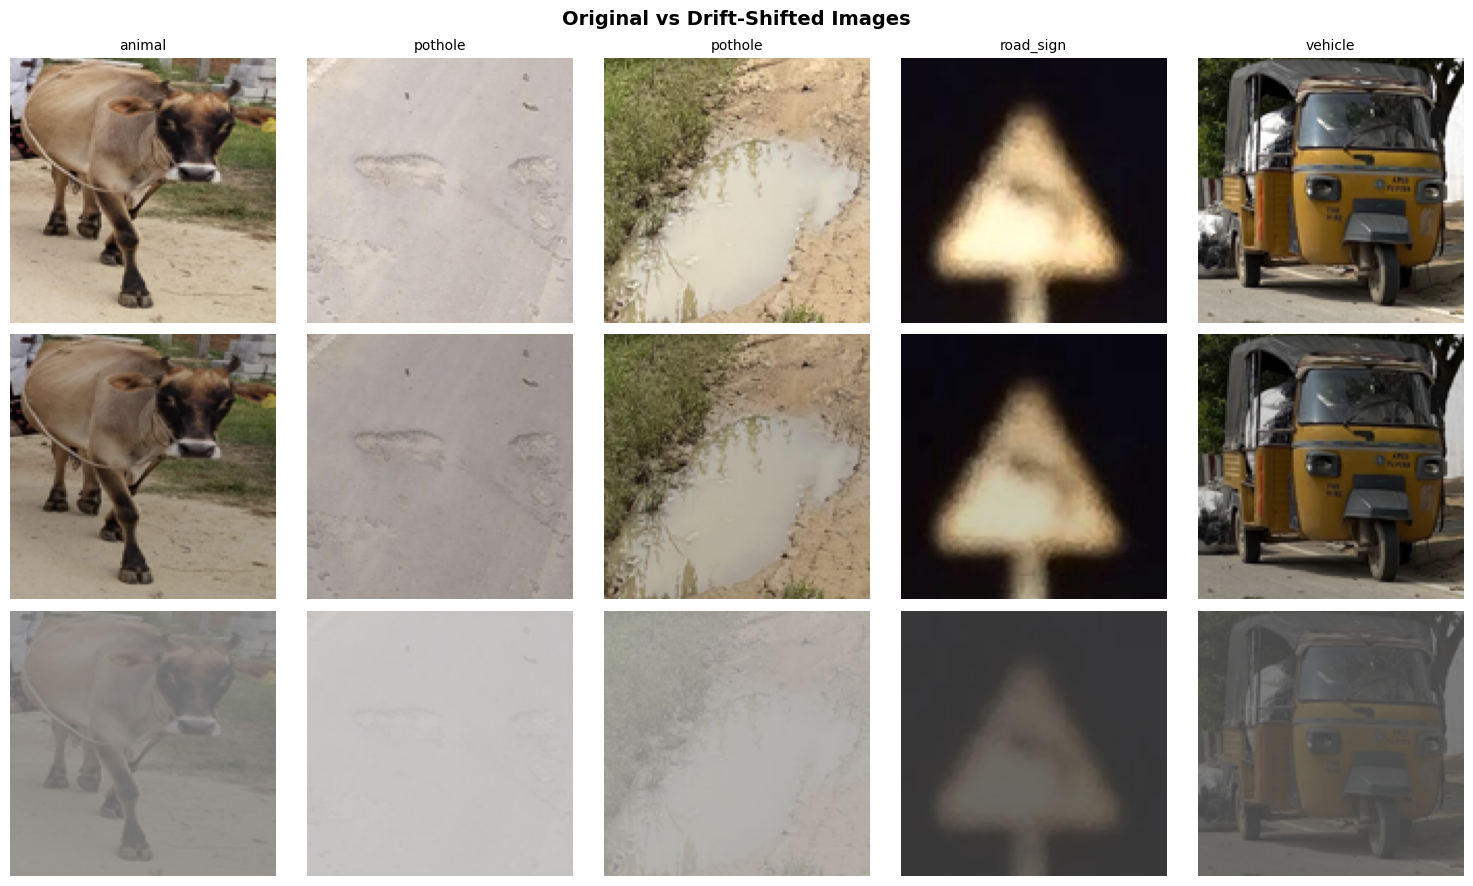

In [6]:
# Visualize original vs shifted images
num_samples = 5
fig, axes = plt.subplots(3, num_samples, figsize=(15, 9))

indices = np.linspace(0, len(test_dataset) - 1, num_samples, dtype=int)

for col, idx in enumerate(indices):
    image_path, label = test_dataset.imgs[idx]
    orig_img = Image.open(image_path).convert('RGB').resize((128, 128))
    bright_img = ImageEnhance.Brightness(orig_img).enhance(0.8)
    contrast_img = ImageEnhance.Contrast(orig_img).enhance(0.2)

    axes[0, col].imshow(orig_img)
    axes[0, col].set_title(class_names[label], fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(bright_img)
    axes[1, col].axis('off')

    axes[2, col].imshow(contrast_img)
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Brightness\n(0.1x)', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('Contrast\n(0.2x)', fontsize=12, fontweight='bold')

plt.suptitle('Original vs Drift-Shifted Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Evaluate Model on Different Data Distributions

In [7]:
def replace_bn_with_identity(module):
    """Recursively replace every nn.BatchNorm2d with nn.Identity.

    The v1 checkpoint was trained with BatchNorm stripped (the "Baseline /
    No Regularization" model), so its state_dict has no BN parameters. The
    architecture here must strip BN too — otherwise load_state_dict fails
    on the missing BN keys (resnet.bn1.*, resnet.layerX.*.bnY.*).
    """
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            setattr(module, name, nn.Identity())
        else:
            replace_bn_with_identity(child)


class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.resnet = resnet18(weights=None)
        replace_bn_with_identity(self.resnet)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)


model = CNNModel(num_classes).to(device)

# Load the TRAINED weights. Fail loudly if missing — serving random weights
# silently produces ~1/num_classes accuracy that looks like a drift bug.
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Trained weights not found at {MODEL_PATH}. "
        f"Run class1/Part_2_Overfitting_and_Generalization.ipynb to generate them."
    )

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print(f"Loaded trained model from {MODEL_PATH}")

Loaded trained model from C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\class2\models\v1\model.pth


In [8]:
def evaluate_dataset(model, loader, device, dataset_name):
    """
    Evaluate model on a dataset.
    Returns accuracy (%) and list of predictions.
    """
    model.eval()
    correct = 0
    total = 0
    predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted.cpu() == labels).sum().item()
            total += labels.size(0)
            predictions.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"  {dataset_name}: {correct}/{total} correct")
    return accuracy, predictions

print("Evaluation function defined")

Evaluation function defined


In [9]:
# Evaluate on different datasets
print("\n" + "="*70)
print("MODEL PERFORMANCE UNDER DATA DRIFT")
print("="*70)

results = {}

try:
    acc_original, pred_original = evaluate_dataset(model, test_loader, device, "Original Test")
    results['Original'] = acc_original
    print(f"\nOriginal Test Set Accuracy: {acc_original:.2f}%")
except Exception as e:
    print(f"\nError evaluating original dataset: {e}")

try:
    acc_brightness, pred_brightness = evaluate_dataset(model, brightness_shifted_loader, device, "Brightness-Shifted")
    results['Brightness-Shifted (0.8x)'] = acc_brightness
    degradation_brightness = acc_original - acc_brightness
    print(f"\nBrightness-Shifted (80% brightness) Accuracy: {acc_brightness:.2f}%")
    print(f"   Degradation: {degradation_brightness:.2f}%")
except Exception as e:
    print(f"\nError evaluating brightness-shifted dataset: {e}")

try:
    acc_contrast, pred_contrast = evaluate_dataset(model, contrast_shifted_loader, device, "Contrast-Shifted")
    results['Contrast-Shifted (0.2x)'] = acc_contrast
    degradation_contrast = acc_original - acc_contrast
    print(acc_original, acc_contrast)
    print(f"\nContrast-Shifted (20% contrast) Accuracy: {acc_contrast:.2f}%")
    print(f"   Degradation: {degradation_contrast:.2f}%")
except Exception as e:
    print(f"\nError evaluating contrast-shifted dataset: {e}")

print("\n" + "="*70)


MODEL PERFORMANCE UNDER DATA DRIFT
  Original Test: 107/117 correct

Original Test Set Accuracy: 91.45%
  Brightness-Shifted: 104/117 correct

Brightness-Shifted (80% brightness) Accuracy: 88.89%
   Degradation: 2.56%
  Contrast-Shifted: 71/117 correct
91.45299145299145 60.68376068376068

Contrast-Shifted (20% contrast) Accuracy: 60.68%
   Degradation: 30.77%



---
## Step 5: Extract Features and Compute KL Divergence

In [10]:
def extract_features(model, loader, device, num_samples=None):
    """
    Extract image features from the layer before classification.
    Returns numpy array of shape (num_samples, feature_dim).
    """
    model.eval()
    features_list = []

    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            images = images.to(device)
            x = model.resnet.conv1(images)
            x = model.resnet.bn1(x)
            x = model.resnet.relu(x)
            x = model.resnet.maxpool(x)
            x = model.resnet.layer1(x)
            x = model.resnet.layer2(x)
            x = model.resnet.layer3(x)
            x = model.resnet.layer4(x)
            x = model.resnet.avgpool(x)
            features = x.view(x.size(0), -1)
            features_list.append(features.cpu().numpy())

            if num_samples and i * len(images) >= num_samples:
                break

    return np.vstack(features_list) if features_list else np.array([])

print("Feature extraction function defined")

Feature extraction function defined


In [11]:
# Extract features from different datasets
print("\nExtracting features from datasets...")

features_original = None
features_brightness = None
features_contrast = None

try:
    features_original = extract_features(model, test_loader, device, num_samples=100)
    print(f"Original features shape: {features_original.shape}")
except Exception as e:
    print(f"Error extracting original features: {e}")

try:
    features_brightness = extract_features(model, brightness_shifted_loader, device, num_samples=100)
    print(f"Brightness-shifted features shape: {features_brightness.shape}")
except Exception as e:
    print(f"Error extracting brightness features: {e}")

try:
    features_contrast = extract_features(model, contrast_shifted_loader, device, num_samples=100)
    print(f"Contrast-shifted features shape: {features_contrast.shape}")
except Exception as e:
    print(f"Error extracting contrast features: {e}")


Extracting features from datasets...
Original features shape: (117, 512)
Brightness-shifted features shape: (117, 512)
Contrast-shifted features shape: (117, 512)


In [12]:
def compute_distribution_metrics(features_dist1, features_dist2):
    """
    Compare two feature distributions using KL divergence.
    Returns KL divergence and histogram data.
    """
    feat1 = features_dist1[:, 0]
    feat2 = features_dist2[:, 0]

    bins = np.linspace(min(feat1.min(), feat2.min()), max(feat1.max(), feat2.max()), 50)
    hist1, _ = np.histogram(feat1, bins=bins)
    hist2, _ = np.histogram(feat2, bins=bins)

    # Normalize to probabilities
    hist1 = hist1 / hist1.sum()
    hist2 = hist2 / hist2.sum()

    # Add epsilon to avoid log(0)
    epsilon = 1e-10
    hist1 = hist1 + epsilon
    hist2 = hist2 + epsilon

    # KL divergence: measures how much dist2 differs from dist1
    kl_div = float(entropy(hist1, hist2))  # scipy entropy(p, q) = KL(p || q)

    return kl_div, hist1, hist2, bins

print("Distribution metrics function defined")

Distribution metrics function defined


In [13]:
# Calculate KL divergence
print("\n" + "="*70)
print("DISTRIBUTION SHIFT METRICS")
print("="*70)

measurements = {}

if features_original is not None and features_brightness is not None:
    try:
        kl_brightness, hist_orig, hist_bright, bins = compute_distribution_metrics(
            features_original, features_brightness
        )
        measurements['brightness'] = {
            'kl_divergence': kl_brightness,
            'hist_orig': hist_orig,
            'hist_shifted': hist_bright,
            'bins': bins
        }
        drift_status = 'HIGH DRIFT' if kl_brightness > 0.5 else 'LOW DRIFT'
        print(f"\nOriginal vs Brightness-Shifted:")
        print(f"   KL Divergence: {kl_brightness:.4f}")
        print(f"   Status: {drift_status}")
    except Exception as e:
        print(f"Error computing brightness metrics: {e}")

if features_original is not None and features_contrast is not None:
    try:
        kl_contrast, hist_orig, hist_cont, bins = compute_distribution_metrics(
            features_original, features_contrast
        )
        measurements['contrast'] = {
            'kl_divergence': kl_contrast,
            'hist_orig': hist_orig,
            'hist_shifted': hist_cont,
            'bins': bins
        }
        drift_status = 'HIGH DRIFT' if kl_contrast > 0.5 else 'LOW DRIFT'
        print(f"\nOriginal vs Contrast-Shifted:")
        print(f"   KL Divergence: {kl_contrast:.4f}")
        print(f"   Status: {drift_status}")
    except Exception as e:
        print(f"Error computing contrast metrics: {e}")

print("\n" + "="*70)


DISTRIBUTION SHIFT METRICS

Original vs Brightness-Shifted:
   KL Divergence: 1.0773
   Status: HIGH DRIFT

Original vs Contrast-Shifted:
   KL Divergence: 7.1754
   Status: HIGH DRIFT



---
## Step 6: Visualize Distribution Shifts

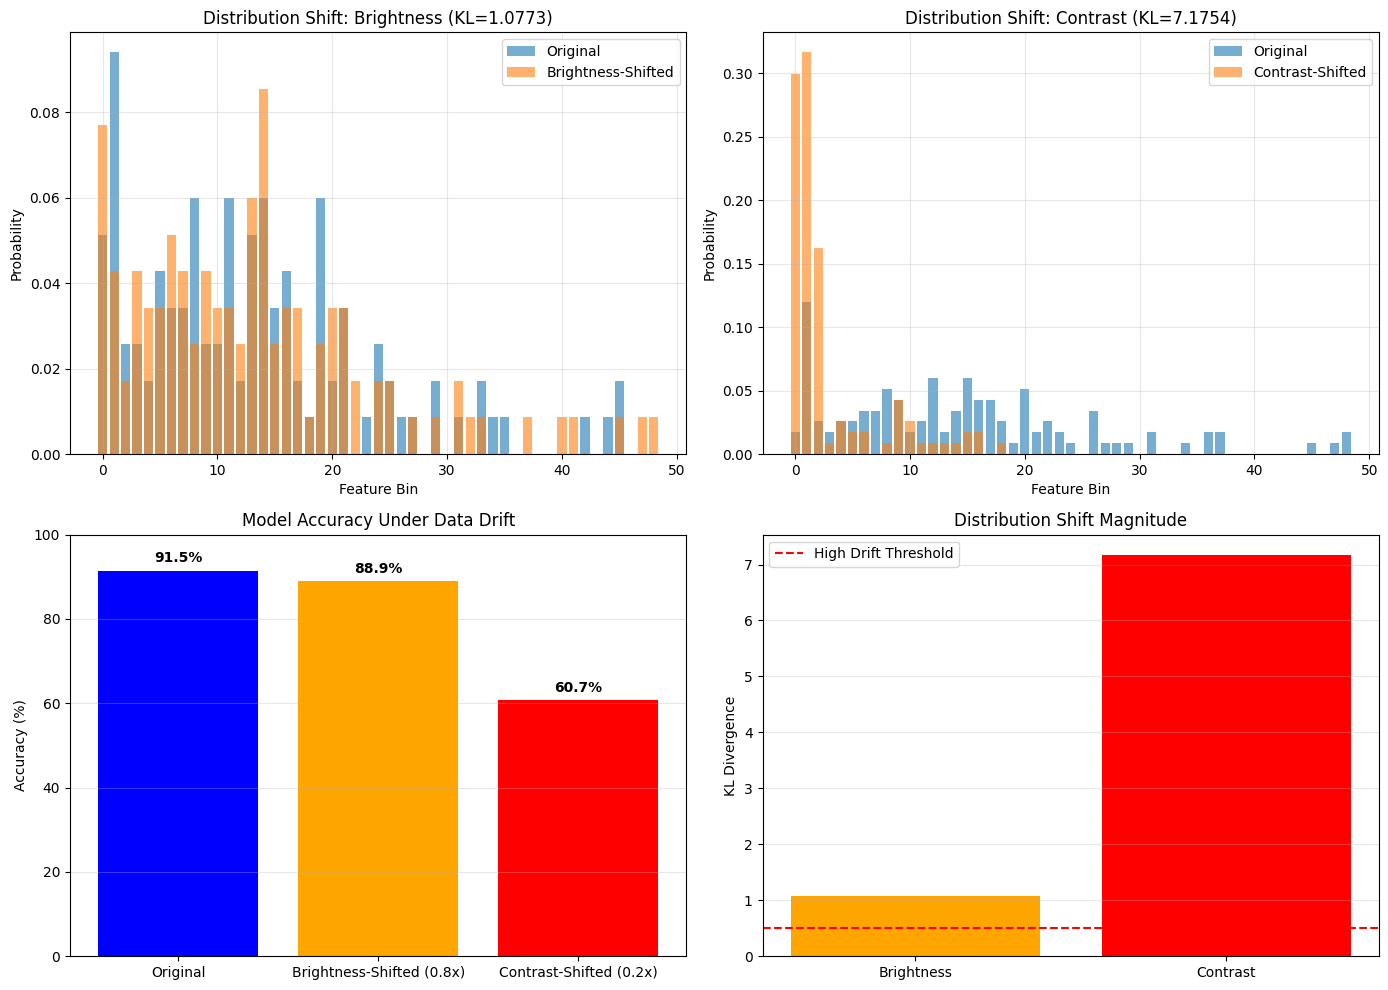

Drift analysis visualization saved


In [14]:
if measurements:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Brightness comparison
    if 'brightness' in measurements:
        m = measurements['brightness']
        axes[0, 0].bar(range(len(m['hist_orig'])), m['hist_orig'], alpha=0.6, label='Original', width=0.8)
        axes[0, 0].bar(range(len(m['hist_shifted'])), m['hist_shifted'], alpha=0.6, label='Brightness-Shifted', width=0.8)
        axes[0, 0].set_xlabel('Feature Bin')
        axes[0, 0].set_ylabel('Probability')
        axes[0, 0].set_title(f'Distribution Shift: Brightness (KL={m["kl_divergence"]:.4f})')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

    # Contrast comparison
    if 'contrast' in measurements:
        m = measurements['contrast']
        axes[0, 1].bar(range(len(m['hist_orig'])), m['hist_orig'], alpha=0.6, label='Original', width=0.8)
        axes[0, 1].bar(range(len(m['hist_shifted'])), m['hist_shifted'], alpha=0.6, label='Contrast-Shifted', width=0.8)
        axes[0, 1].set_xlabel('Feature Bin')
        axes[0, 1].set_ylabel('Probability')
        axes[0, 1].set_title(f'Distribution Shift: Contrast (KL={m["kl_divergence"]:.4f})')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

    # Accuracy comparison
    if results:
        axes[1, 0].bar(results.keys(), results.values(), color=['blue', 'orange', 'red'])
        axes[1, 0].set_ylabel('Accuracy (%)')
        axes[1, 0].set_title('Model Accuracy Under Data Drift')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        axes[1, 0].set_ylim([0, 100])
        for i, (k, v) in enumerate(results.items()):
            axes[1, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    # KL Divergence comparison
    kl_values = {}
    if 'brightness' in measurements:
        kl_values['Brightness'] = measurements['brightness']['kl_divergence']
    if 'contrast' in measurements:
        kl_values['Contrast'] = measurements['contrast']['kl_divergence']
    if kl_values:
        axes[1, 1].bar(kl_values.keys(), kl_values.values(), color=['orange', 'red'])
        axes[1, 1].set_ylabel('KL Divergence')
        axes[1, 1].set_title('Distribution Shift Magnitude')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].axhline(y=0.5, color='r', linestyle='--', label='High Drift Threshold')
        axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('data_drift_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Drift analysis visualization saved")
else:
    print("No measurements to visualize")

---
## Step 7: Drift Detection System

In [15]:
class DriftDetector:
    """
    Automated drift detection system.
    Monitors model performance and input distribution.
    """

    def __init__(self, baseline_accuracy, accuracy_threshold=5.0, kl_threshold=0.5):
        """
        Args:
            baseline_accuracy: Original model accuracy
            accuracy_threshold: Alert if accuracy drops > this % (default 5%)
            kl_threshold: Alert if KL divergence > this value (default 0.5)
        """
        self.baseline_accuracy = baseline_accuracy
        self.accuracy_threshold = accuracy_threshold
        self.kl_threshold = kl_threshold
        self.alerts = []

    def check_accuracy_drift(self, current_accuracy, dataset_name):
        """Check if current accuracy shows significant degradation."""
        degradation = self.baseline_accuracy - current_accuracy
        alert = {
            'type': 'ACCURACY_DRIFT',
            'dataset': dataset_name,
            'baseline': self.baseline_accuracy,
            'current': current_accuracy,
            'degradation': degradation,
            'triggered': degradation > self.accuracy_threshold
        }
        self.alerts.append(alert)
        return alert

    def check_distribution_drift(self, kl_score, dataset_name):
        """Check if input distribution has shifted significantly."""
        alert = {
            'type': 'DISTRIBUTION_DRIFT',
            'dataset': dataset_name,
            'kl_divergence': kl_score,
            'threshold': self.kl_threshold,
            'triggered': kl_score > self.kl_threshold
        }
        self.alerts.append(alert)
        return alert

    def generate_report(self):
        """Generate drift detection report."""
        triggered_alerts = [a for a in self.alerts if a.get('triggered', False)]
        return {
            'total_checks': len(self.alerts),
            'alerts_triggered': len(triggered_alerts),
            'recommendation': 'RETRAIN' if triggered_alerts else 'MONITOR',
            'details': triggered_alerts
        }

print("DriftDetector class defined")

DriftDetector class defined


In [16]:
# Run drift detection
if results:
    print("\n" + "="*70)
    print("DRIFT DETECTION SYSTEM")
    print("="*70)

    baseline_acc = results.get('Original', 0)
    detector = DriftDetector(
        baseline_accuracy=baseline_acc,
        accuracy_threshold=5.0,
        kl_threshold=0.5
    )

    # Check accuracy drift
    if 'Brightness-Shifted (0.8x)' in results:
        alert = detector.check_accuracy_drift(results['Brightness-Shifted (0.8x)'], 'Brightness-Shifted')
        status = 'TRIGGERED' if alert['triggered'] else 'NORMAL'
        print(f"\nAccuracy Drift Check (Brightness): {status}")
        print(f"  Baseline: {alert['baseline']:.2f}%  Current: {alert['current']:.2f}%  Degradation: {alert['degradation']:.2f}%")

    if 'Contrast-Shifted (0.2x)' in results:
        alert = detector.check_accuracy_drift(results['Contrast-Shifted (0.2x)'], 'Contrast-Shifted')
        status = 'TRIGGERED' if alert['triggered'] else 'NORMAL'
        print(f"\nAccuracy Drift Check (Contrast): {status}")
        print(f"  Baseline: {alert['baseline']:.2f}%  Current: {alert['current']:.2f}%  Degradation: {alert['degradation']:.2f}%")

    # Check distribution drift
    if 'brightness' in measurements:
        alert = detector.check_distribution_drift(measurements['brightness']['kl_divergence'], 'Brightness-Shifted')
        status = 'TRIGGERED' if alert['triggered'] else 'NORMAL'
        print(f"\nDistribution Drift Check (Brightness): {status}")
        print(f"  KL Divergence: {alert['kl_divergence']:.4f}  Threshold: {alert['threshold']}")

    if 'contrast' in measurements:
        alert = detector.check_distribution_drift(measurements['contrast']['kl_divergence'], 'Contrast-Shifted')
        status = 'TRIGGERED' if alert['triggered'] else 'NORMAL'
        print(f"\nDistribution Drift Check (Contrast): {status}")
        print(f"  KL Divergence: {alert['kl_divergence']:.4f}  Threshold: {alert['threshold']}")

    # Final report
    report = detector.generate_report()
    print("\n" + "="*70)
    print("DRIFT DETECTION REPORT")
    print("="*70)
    print(f"Total Checks: {report['total_checks']}")
    print(f"Alerts Triggered: {report['alerts_triggered']}")
    print(f"Recommendation: {report['recommendation']}")

    if report['recommendation'] == 'RETRAIN':
        print("\nACTION REQUIRED:")
        print("   1. Collect new training data from production")
        print("   2. Retrain model on combined dataset")
        print("   3. Validate on holdout test set")
        print("   4. Deploy new version using canary deployment")
    else:
        print("\nMODEL IS STABLE - Continue monitoring")


DRIFT DETECTION SYSTEM

Accuracy Drift Check (Brightness): NORMAL
  Baseline: 91.45%  Current: 88.89%  Degradation: 2.56%

Accuracy Drift Check (Contrast): TRIGGERED
  Baseline: 91.45%  Current: 60.68%  Degradation: 30.77%

Distribution Drift Check (Brightness): TRIGGERED
  KL Divergence: 1.0773  Threshold: 0.5

Distribution Drift Check (Contrast): TRIGGERED
  KL Divergence: 7.1754  Threshold: 0.5

DRIFT DETECTION REPORT
Total Checks: 4
Alerts Triggered: 3
Recommendation: RETRAIN

ACTION REQUIRED:
   1. Collect new training data from production
   2. Retrain model on combined dataset
   3. Validate on holdout test set
   4. Deploy new version using canary deployment


---
## Summary Report

In [17]:
if results or measurements:
    print("\n" + "="*70)
    print("SUMMARY TABLE")
    print("="*70 + "\n")

    summary_data = []

    if 'Original' in results:
        summary_data.append({
            'Dataset': 'Original',
            'Accuracy': f"{results['Original']:.2f}%",
            'KL Div': 'Baseline',
            'Drift Status': 'Baseline'
        })

    if 'Brightness-Shifted (0.8x)' in results:
        kl_val = measurements['brightness']['kl_divergence'] if 'brightness' in measurements else 'N/A'
        kl_str = f"{kl_val:.4f}" if isinstance(kl_val, float) else kl_val
        drift_status = 'HIGH' if isinstance(kl_val, float) and kl_val > 0.5 else 'LOW'
        summary_data.append({
            'Dataset': 'Brightness-Shifted',
            'Accuracy': f"{results['Brightness-Shifted (0.8x)']:.2f}%",
            'KL Div': kl_str,
            'Drift Status': drift_status
        })

    if 'Contrast-Shifted (0.2x)' in results:
        kl_val = measurements['contrast']['kl_divergence'] if 'contrast' in measurements else 'N/A'
        kl_str = f"{kl_val:.4f}" if isinstance(kl_val, float) else kl_val
        drift_status = 'HIGH' if isinstance(kl_val, float) and kl_val > 0.5 else 'LOW'
        summary_data.append({
            'Dataset': 'Contrast-Shifted',
            'Accuracy': f"{results['Contrast-Shifted (0.2x)']:.2f}%",
            'KL Div': kl_str,
            'Drift Status': drift_status
        })

    if summary_data:
        df_summary = pd.DataFrame(summary_data)
        print(df_summary.to_string(index=False))
        print("\n" + "="*70)


SUMMARY TABLE

           Dataset Accuracy   KL Div Drift Status
          Original   91.45% Baseline     Baseline
Brightness-Shifted   88.89%   1.0773         HIGH
  Contrast-Shifted   60.68%   7.1754         HIGH



---
## Key Takeaways

1. **Real models face data drift**: Lighting changes, camera degradation, seasonal shifts — the data in production differs from training data.

2. **Drift causes silent accuracy loss**: The model doesn't crash — it just gets worse. Without monitoring, you won't know.

3. **KL Divergence quantifies shift**: Measures how different the current input distribution is from the training distribution. Higher values mean more drift.

4. **Automated detection enables fast response**:
   - Set thresholds: accuracy drop > 5%, KL divergence > 0.5
   - Monitor continuously in production
   - Trigger retraining when thresholds are exceeded

5. **Mitigation strategies**:
   - Continuous retraining on fresh data
   - Data augmentation during training
   - Ensemble methods
   - Domain adaptation techniques

### Production Workflow
```
Train model -> Deploy with monitoring -> Detect drift
    -> Alert team -> Collect new data -> Retrain
    -> Validate -> Deploy new version (canary) -> Continue monitoring
```